In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import scipy

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

from src import utils as ut

In [2]:
df = pd.read_csv('../../data/processed/dataset_final.csv')
df

,año,comunidad_autonoma,poblacion,pib_total,pib_pc,ingresos_pc,renta_pc,renta_media,renta_mediana,tasa_natalidad,...,paro,gasto_elevado_vivienda,falta_espacio_vivienda,retrasos_pagos,riesgo_pobreza,dificultad_fin_mes,desigualdad_ing(S80/S20),inc_gastos_imprevistos,precio_venta_m2,precio_alquiler_m2
0,2009,Andalucía,7627743.0,145802256.0,19.114731,9437.0,11869.0,143930.0,126950.0,11.48,...,17.73,8.6,5.7,10.6,27.7,71.8,6.0,45.7,1757.50,7.27
1,2010,Andalucía,7666919.0,145853901.0,19.023796,9882.0,11773.0,141520.0,120860.0,11.10,...,25.24,7.8,4.6,12.9,28.1,73.9,6.2,52.2,1713.33,6.85
2,2011,Andalucía,7693947.0,144494494.0,18.780282,9793.0,11797.0,13310.0,113690.0,10.72,...,27.77,11.2,7.5,13.8,34.5,70.5,7.3,49.6,1723.42,6.72
3,2012,Andalucía,7702875.0,139052618.0,18.052041,9241.0,11155.0,133910.0,111170.0,10.30,...,30.13,8.7,6.6,15.5,35.6,71.6,6.2,51.4,1579.42,6.43
4,2013,Andalucía,7710575.0,137294091.0,17.805947,9361.0,11100.0,127050.0,108660.0,9.71,...,34.35,9.2,6.4,13.4,40.1,75.4,6.6,55.5,1443.42,6.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2018,Rioja,280018.0,8649852.0,30.890343,12561.0,16401.0,17490.0,15410.0,7.45,...,12.00,9.4,0.0,7.9,19.1,37.8,5.7,30.3,1180.17,5.89
262,2019,Rioja,279568.0,8889997.0,31.799051,12589.0,16765.0,186610.0,165770.0,7.66,...,10.40,5.8,2.1,4.9,17.5,25.4,5.0,19.0,1205.67,6.21
263,2020,Rioja,279704.0,8186915.0,29.269925,13371.0,16489.0,196980.0,175890.0,7.33,...,9.96,4.6,2.6,8.2,16.9,27.7,4.7,24.5,1215.08,6.58
264,2021,Rioja,278905.0,8735750.0,31.321597,14303.0,16951.0,187580.0,17420.0,6.94,...,10.80,8.2,3.7,8.0,16.8,32.3,5.1,22.5,1238.25,6.83


In [3]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [4]:
df_com = filtrar_columna(df, 'comunidad_autonoma')

In [5]:
df_com[0].index[0]

'Andalucía'

In [6]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}
len(corr_matrices)

19

In [7]:
corr_matrices['Madrid']

,año,poblacion,pib_total,pib_pc,ingresos_pc,renta_pc,renta_media,renta_mediana,tasa_natalidad,tasa_suicidio,...,paro,gasto_elevado_vivienda,falta_espacio_vivienda,retrasos_pagos,riesgo_pobreza,dificultad_fin_mes,desigualdad_ing(S80/S20),inc_gastos_imprevistos,precio_venta_m2,precio_alquiler_m2
año,1.000000,0.978688,0.879551,0.763119,0.633040,0.870661,-0.375323,0.141825,-0.991715,0.767841,...,-0.250544,-0.420338,0.251705,0.080462,0.065456,-0.806817,-0.020099,-0.710619,0.406156,0.820098
poblacion,0.978688,1.000000,0.801787,0.658436,0.495436,0.800765,-0.370348,0.057222,-0.969187,0.795074,...,-0.148984,-0.377158,0.181341,-0.037139,0.221345,-0.745716,0.098674,-0.670941,0.248656,0.772611
pib_total,0.879551,0.801787,1.000000,0.977662,0.645768,0.966251,-0.351955,0.284020,-0.858562,0.637166,...,-0.488500,-0.338561,0.103379,0.079173,-0.194836,-0.847905,-0.108253,-0.762478,0.617397,0.875347
pib_pc,0.763119,0.658436,0.977662,1.000000,0.635147,0.937258,-0.313234,0.335873,-0.739540,0.526360,...,-0.566552,-0.291642,0.065540,0.110685,-0.322132,-0.808263,-0.165928,-0.729789,0.688380,0.832869
ingresos_pc,0.633040,0.495436,0.645768,0.635147,1.000000,0.652901,-0.219386,0.443621,-0.673566,0.211609,...,-0.445976,-0.701403,0.639455,0.465343,-0.626437,-0.660453,-0.640416,-0.427315,0.836781,0.668694
renta_pc,0.870661,0.800765,0.966251,0.937258,0.652901,1.000000,-0.431845,0.282345,-0.853140,0.668769,...,-0.558357,-0.381889,0.199494,0.104490,-0.230687,-0.925617,-0.091800,-0.857632,0.640937,0.917703
renta_media,-0.375323,-0.370348,-0.351955,-0.313234,-0.219386,-0.431845,1.000000,-0.083135,0.391257,-0.311710,...,0.150946,-0.005383,0.116719,0.010279,-0.031224,0.452945,-0.112069,0.342069,-0.274523,-0.356784
renta_mediana,0.141825,0.057222,0.284020,0.335873,0.443621,0.282345,-0.083135,1.000000,-0.199659,-0.184580,...,-0.504230,-0.090097,0.166410,0.221938,-0.454929,-0.320696,-0.363120,-0.090737,0.528084,0.390274
tasa_natalidad,-0.991715,-0.969187,-0.858562,-0.739540,-0.673566,-0.853140,0.391257,-0.199659,1.000000,-0.709251,...,0.288884,0.477329,-0.313854,-0.116804,-0.010617,0.817848,0.100382,0.693781,-0.452823,-0.841102
tasa_suicidio,0.767841,0.795074,0.637166,0.526360,0.211609,0.668769,-0.311710,-0.184580,-0.709251,1.000000,...,-0.121161,-0.127961,0.026078,0.035206,0.331226,-0.596599,0.287182,-0.731247,0.062051,0.570797


In [8]:
def corr_to_vector(corr_df):
    '''Convierte una matriz de correlación en un vector de una dimensión con todos los valores cruzados.'''
    return (corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack())

# DataFrame: filas = datasets, columnas = pares de variables
corr_vectors = pd.DataFrame([corr_to_vector(matriz) for matriz in corr_matrices.values()])

corr_vectors.index = [key for key in corr_matrices.keys()]
corr_vectors

año                                            \
                     poblacion pib_total    pib_pc ingresos_pc  renta_pc   
Andalucía             0.843310  0.796477  0.764902    0.307417  0.830452   
Aragón               -0.732143  0.805034  0.805885    0.657572  0.836420   
Asturias             -0.994330  0.554838  0.729260    0.382205  0.863784   
Balears               0.990889  0.739768  0.541000    0.484590  0.767489   
Canarias              0.980783  0.614250  0.467127    0.515176  0.796492   
Cantabria            -0.811445  0.742284  0.755632    0.459939  0.843329   
Castilla - La Mancha -0.483599  0.723787  0.723167    0.336975  0.873895   
Castilla Y León      -0.993971  0.715210  0.825497    0.780713  0.878670   
Cataluña              0.931381  0.849957  0.797477    0.706280  0.827202   
Ceuta                 0.577390  0.809736  0.676601    0.562374  0.681798   
Comunitat Valenciana  0.965446  0.803639  0.761417    0.350546  0.852402   
Extremadura          -0.957544  0.825785  0.855555    0.345423  0.913446   
Galicia              -0.996784  0.817789  0.862043    0.887528  0.891046   
Madrid                0.978688  0.879551  0.763119    0.633040  0.870661   
Melilla               0.911776  0.870554  0.499959    0.176761  0.627456   
Murcia                0.998075  0.856204  0.772676    0.227853  0.841843   
Navarra               0.937761  0.837942  0.744617    0.370039  0.656848   
País Vasco           -0.273248  0.823202  0.817188    0.678866  0.803000   
Rioja                 0.708159  0.781367  0.734477    0.811014  0.859671   

                                                                             \
                     renta_media renta_mediana tasa_natalidad tasa_suicidio   
Andalucía               0.298569      0.400760      -0.992357     -0.469589   
Aragón                 -0.194782      0.527624      -0.986057      0.326137   
Asturias                0.364704      0.039326      -0.981548      0.173727   
Balears                -0.085185      0.105509      -0.982874     -0.657127   
Canarias               -0.111297      0.204700      -0.980841      0.236305   
Cantabria               0.057498      0.532929      -0.996174      0.537352   
Castilla - La Mancha    0.289231     -0.230107      -0.991296     -0.027022   
Castilla Y León         0.351876     -0.105910      -0.990941      0.442991   
Cataluña                0.477157      0.172955      -0.991957      0.652973   
Ceuta                   0.480960     -0.443378      -0.954624     -0.163201   
Comunitat Valenciana    0.508993      0.309519      -0.991228      0.169689   
Extremadura             0.261359      0.331319      -0.981116      0.127759   
Galicia                 0.282999      0.223958      -0.981640     -0.113362   
Madrid                 -0.375323      0.141825      -0.991715      0.767841   
Melilla                 0.200095      0.066936      -0.835753     -0.484784   
Murcia                  0.574676     -0.332443      -0.991297      0.218028   
Navarra                 0.185241      0.066936      -0.985858     -0.366774   
País Vasco             -0.211021      0.457219      -0.980627     -0.216717   
Rioja                   0.178485     -0.188456      -0.988903     -0.153608   

                                     ...       dificultad_fin_mes  \
                     tasa_homicidio  ... desigualdad_ing(S80/S20)   
Andalucía                 -0.458932  ...                 0.590883   
Aragón                    -0.235263  ...                 0.630566   
Asturias                  -0.711821  ...                -0.446911   
Balears                   -0.422179  ...                 0.406413   
Canarias                  -0.073211  ...                 0.544058   
Cantabria                  0.132531  ...                 0.007289   
Castilla - La Mancha       0.193652  ...                 0.598385   
Castilla Y León            0.063890  ...                 0.696254   
Cataluña                  -0.660504  ...                 0.480933   
Ceuta      

In [9]:
corr_summary = pd.DataFrame({'mean': corr_vectors.mean(), 'std': corr_vectors.std()})
corr_summary.head()

mean       std
año poblacion    0.188452  0.871445
    pib_total    0.781441  0.084470
    pib_pc       0.731453  0.112261
    ingresos_pc  0.509174  0.206338
    renta_pc     0.816627  0.079882

In [10]:
def std_category(std):
    if std < 0.05:
        return "low"       # círculo
    elif std < 0.10:
        return "medium"    # cuadrado
    else:
        return "high"      # triángulo

corr_summary["std_cat"] = corr_summary["std"].apply(std_category)
corr_summary

mean       std std_cat
año                      poblacion           0.188452  0.871445    high
                         pib_total           0.781441  0.084470  medium
                         pib_pc              0.731453  0.112261    high
                         ingresos_pc         0.509174  0.206338    high
                         renta_pc            0.816627  0.079882  medium
...                                               ...       ...     ...
desigualdad_ing(S80/S20) precio_venta_m2    -0.053721  0.464879    high
                         precio_alquiler_m2 -0.357261  0.328886    high
inc_gastos_imprevistos   precio_venta_m2    -0.118264  0.448083    high
                         precio_alquiler_m2 -0.330514  0.390208    high
precio_venta_m2          precio_alquiler_m2  0.307177  0.404925    high

[231 rows x 3 columns]

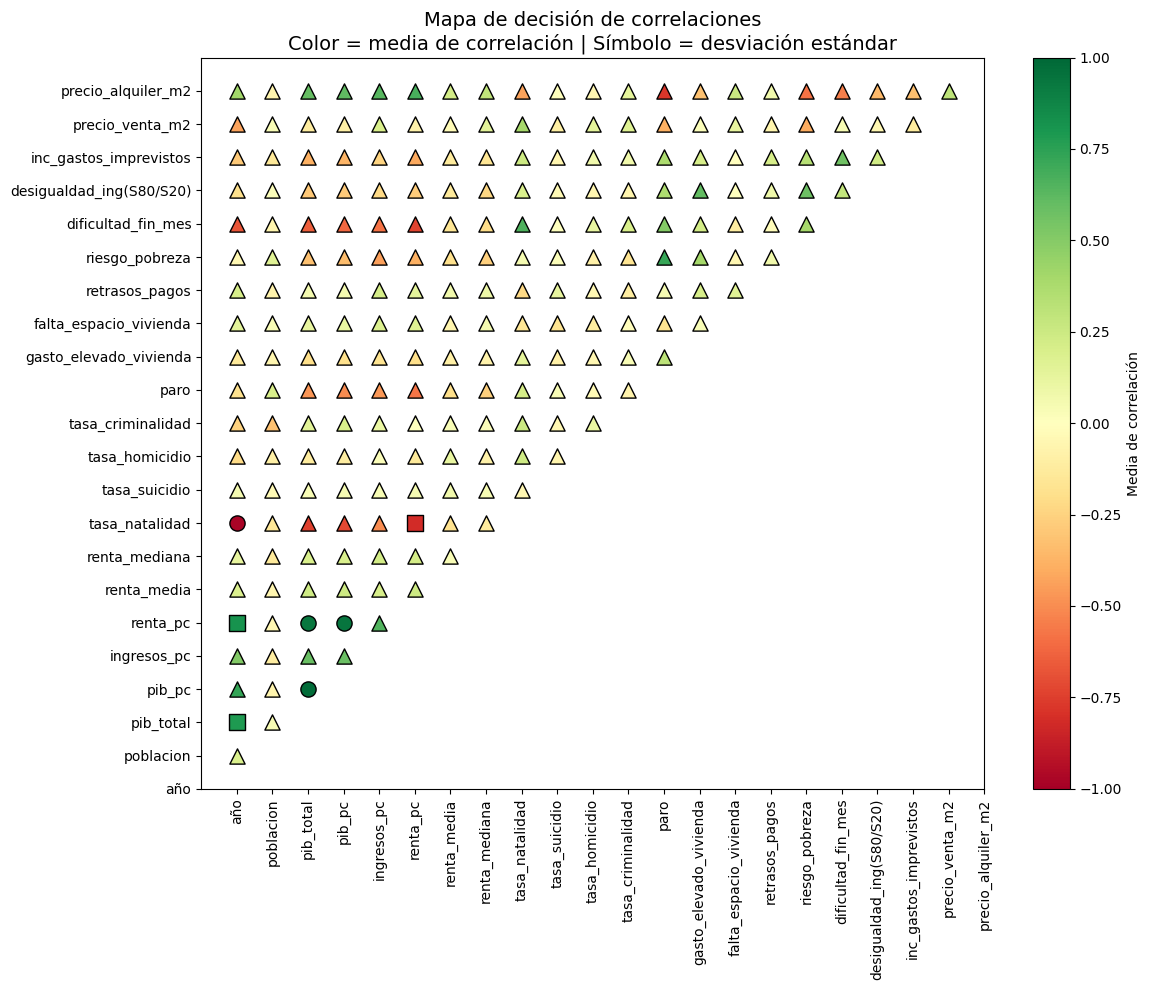

In [11]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in corr_summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",     # círculo
        "medium": "s",  # cuadrado
        "high": "^"     # triángulo
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black"
    )

# Ejes
ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media de correlación | Símbolo = desviación estándar",
    fontsize=14
)

# Barra de color
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Tras esta primera representación se observan muchos triángulos y pocas variables con una correlación alta. Tras una busqueda en Internet se aplican diferentes palancas para conseguir evidencias relacionales más claras*

🔹 PALANCA 1 — Fisher Z-transform (CLAVE)

Promediar correlaciones en r es mala idea.

Solución:

Transformar primero:

r → z

promediar

volver a r

🔹 Qué hace Fisher Z

Transforma:

𝑧
=
tanh
⁡
−
1
(
𝑟
)
z=tanh
−1
(r)

Propiedades clave:

Distribución aproximadamente normal

Varianza independiente del valor de r

Pensado EXACTAMENTE para:

comparar

promediar

hacer meta-análisis

Después:

𝑟
=
tanh
⁡
(
𝑧
)
r=tanh(z)

👉 No cambia la correlación, cambia cómo la agregas.

🔹 Cuándo usar Fisher Z

✔️ Siempre que:

Promedias correlaciones

Comparas correlaciones entre muestras

Quieres estabilidad estadística

📌 En tu caso: obligatorio, no opcional.

In [12]:
from numpy import arctanh, tanh

z_vectors = corr_vectors.apply(np.arctanh)
z_mean = z_vectors.mean()
z_std = z_vectors.std()

summary = pd.DataFrame({
    "mean": np.tanh(z_mean),
    "std": z_std
})

🔹 PALANCA 2 — Relajar el concepto de “estabilidad”

Ahora mismo estás siendo muy duro.

Ejemplo más realista:

In [13]:
def std_category(std):
    if std < 0.10:
        return "low"
    elif std < 0.20:
        return "medium"
    else:
        return "high"


🔹 PALANCA 3 — Estabilidad de signo (muy potente)

Aunque el valor fluctúe, ¿el signo se mantiene?

In [14]:
sign_consistency = (corr_vectors > 0).mean().abs()

🔹 PALANCA 4 — Filtrar por magnitud mínima

Muchas correlaciones son “ruido pequeño”.

In [15]:
mask = corr_vectors.abs().mean() > 0.2
corr_vectors = corr_vectors.loc[:, mask]

4️⃣ Código COMPLETO aplicando 1–2–3–4

4.1 Fisher Z + estadísticas

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fisher Z transform
z_vectors = corr_vectors.apply(np.arctanh)

summary = pd.DataFrame({
    "mean_r": np.tanh(z_vectors.mean()),   # media correcta
    "std_z": z_vectors.std(),               # variabilidad real
    "sign_consistency": (corr_vectors > 0).mean().abs()
})


4.2 Filtrar por magnitud (palanca 4)

In [17]:
summary = summary[summary["mean_r"].abs() > 0.2]

In [18]:
summary

mean_r     std_z  \
año                      poblacion               0.335642  2.054077   
                         pib_total               0.792717  0.197007   
                         pib_pc                  0.746972  0.220101   
                         ingresos_pc             0.546629  0.332427   
                         renta_pc                0.828775  0.215947   
...                                                   ...       ...   
dificultad_fin_mes       precio_alquiler_m2     -0.662432  0.746779   
desigualdad_ing(S80/S20) inc_gastos_imprevistos  0.261882  0.438739   
                         precio_alquiler_m2     -0.396385  0.389977   
inc_gastos_imprevistos   precio_alquiler_m2     -0.397741  0.534474   
precio_venta_m2          precio_alquiler_m2      0.386982  0.557885   

                                                 sign_consistency  
año                      poblacion                       0.578947  
                         pib_total                       1.000000  
                         pib_pc                          1.000000  
                         ingresos_pc                     1.000000  
                         renta_pc                        1.000000  
...                                                           ...  
dificultad_fin_mes       precio_alquiler_m2              0.105263  
desigualdad_ing(S80/S20) inc_gastos_imprevistos          0.789474  
                         precio_alquiler_m2              0.210526  
inc_gastos_imprevistos   precio_alquiler_m2              0.210526  
precio_venta_m2          precio_alquiler_m2              0.736842  

[112 rows x 3 columns]

4.3 Clasificar estabilidad (palanca 2)

In [19]:
def std_category(std):
    if std < 0.20:
        return "low"
    elif std < 0.40:
        return "medium"
    else:
        return "high"

summary["std_cat"] = summary["std_z"].apply(std_category)


5️⃣ Código de la GRÁFICA (final)

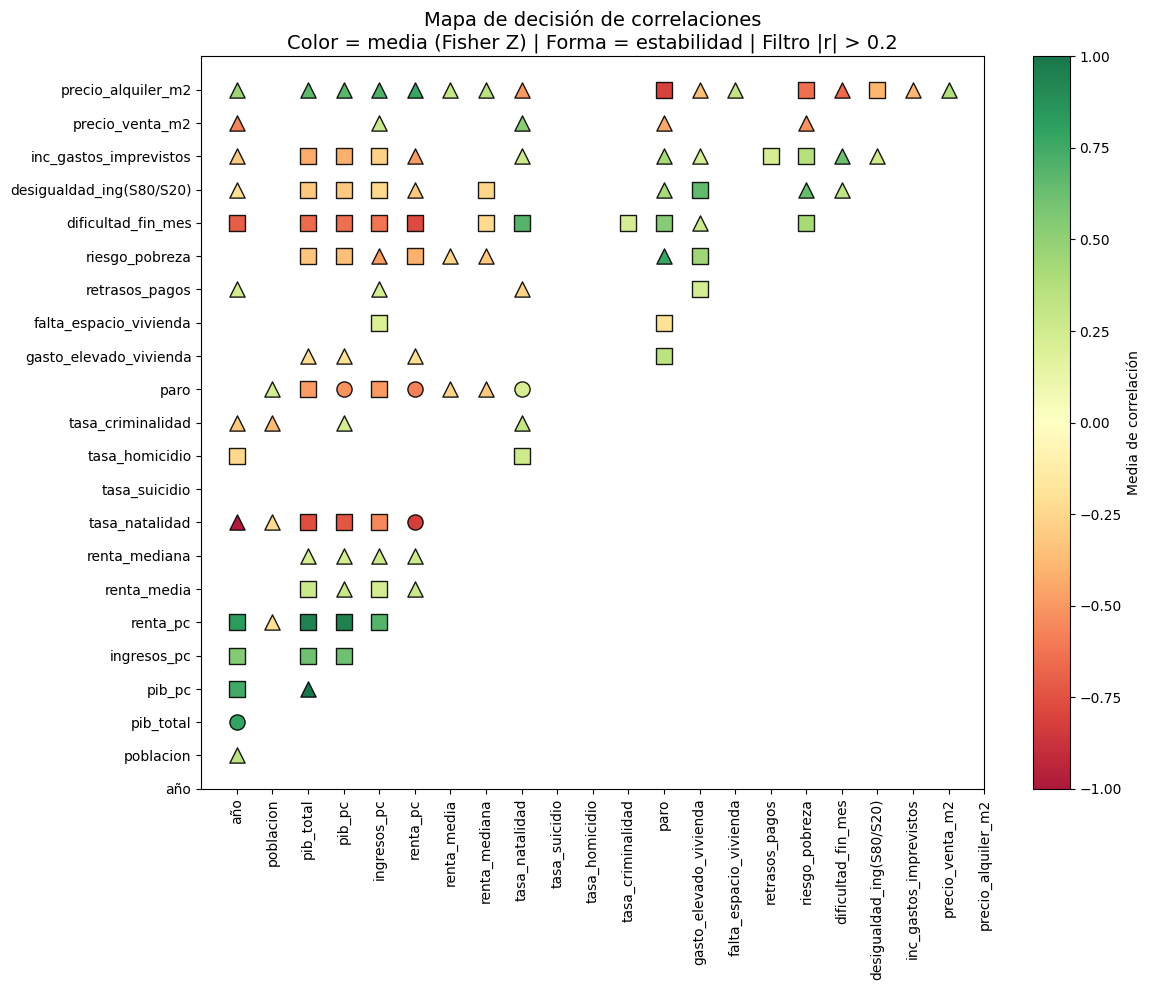

In [20]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x, y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media (Fisher Z) | Forma = estabilidad | Filtro |r| > 0.2",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Para una mayor agilidad en el análisis se crea la matriz simétrica y así tener el cuadro completo a la hora de buscar correlaciones.*

In [21]:
summary_sym = summary.copy()

# Intercambiar los pares (A, B) → (B, A)
summary_sym.index = pd.MultiIndex.from_tuples(
    [(j, i) for i, j in summary.index],
    names=summary.index.names
)

# Unir original + simétrica
summary_full = pd.concat([summary, summary_sym])


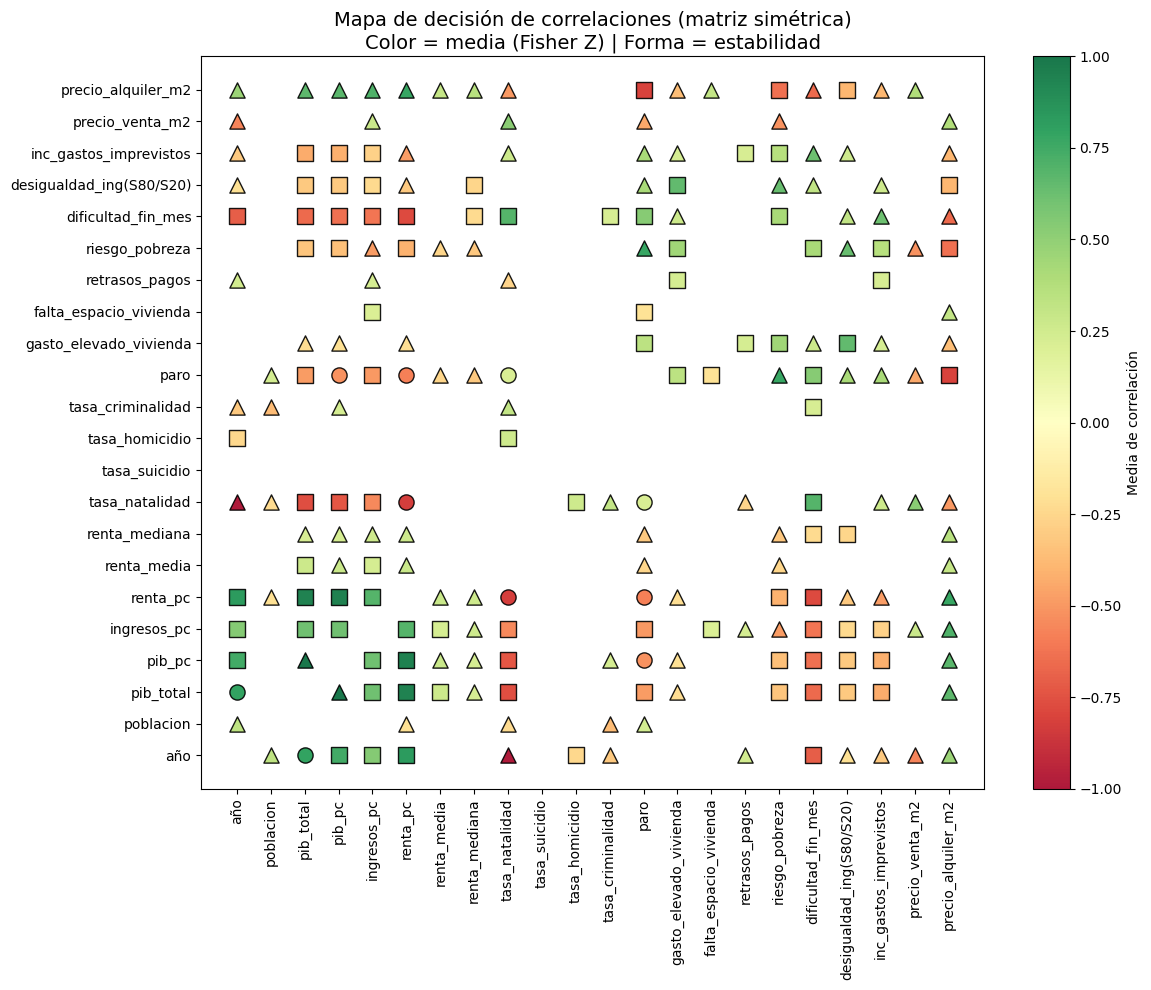

In [22]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary_full.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones (matriz simétrica)\n"
    "Color = media (Fisher Z) | Forma = estabilidad",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


precio_alquiler_m2 - paro / riesgo pobreza

precio_venta_m2 - Nada

inc_gastos_imprevistos - Nada

Desigualdad - Gasto_elevado_vivienda

Dificultad_fin - Natalidad / Renta PC

Rieso Pobreza - Tasa de Criminalidad

Retrasos pagos - Nada

Falta espacio vivienda - Nada

Paro - Nada

Suicidios - Nada (Mencionar el cambio de datos en 2013)

Tasa Criminalidad - Nada

Tasa homicidios - Nada

Tasa Natalidad - Año, Renta PC, PIB Total, Dificultad Fin de mes

Renta Mediana - Nada

Renta Media - Nada

Renta PC - Año, Pib total, pib per capita, Tasa de Natalidad, Dificultad fin de mes

Ingresos - Año, PIB total, Pib per capita, Renta PC

PIB PC - Año, PIB Total, Ingresos PC, Renta PC, Tasa Natalidad

In [23]:
corr_matrices['Madrid'].columns

Index(['año', 'poblacion', 'pib_total', 'pib_pc', 'ingresos_pc', 'renta_pc',
       'renta_media', 'renta_mediana', 'tasa_natalidad', 'tasa_suicidio',
       'tasa_homicidio', 'tasa_criminalidad', 'paro', 'gasto_elevado_vivienda',
       'falta_espacio_vivienda', 'retrasos_pagos', 'riesgo_pobreza',
       'dificultad_fin_mes', 'desigualdad_ing(S80/S20)',
       'inc_gastos_imprevistos', 'precio_venta_m2', 'precio_alquiler_m2'],
      dtype='object')

In [24]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'paro', 'precio_alquiler_m2',alpha = 0.05)

Coeficiente de correlación de Spearman entre paro y precio_alquiler_m2

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [-0.912, -0.886, -0.908, -0.846, -0.847, -0.899, -0.919, -0.67, -0.802, -0.899, -0.916, -0.938, -0.802, -0.825, -0.881, -0.653, -0.761, -0.775]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Ceuta']
 [0.145]


## Precio de Alquiler - Paro

Se descartan las ciudades autónomas de Ceuta y Melilla debido a su reducida población, lo que limita su representatividad en un análisis comparativo a nivel de comunidades autónomas.


El análisis de correlación entre la tasa de paro y el precio del alquiler por metro cuadrado muestra la existencia de una relación significativa entre ambas variables en varias comunidades autónomas.

Este resultado permite rechazar la hipótesis nula de independencia entre el paro y el precio del alquiler, aportando evidencia a favor de la hipótesis alternativa, según la cual un aumento del paro se asocia con una disminución del precio del alquiler por metro cuadrado.

Seguidamente, se representarán de forma independiente las series temporales de la tasa de paro y del precio del alquiler por metro cuadrado, seleccionando comunidades autónomas con distintos niveles de correlación: aquellas con mayor correlación, menor correlación y un caso intermedio.

Estas visualizaciones permitirán analizar visualmente la evolución temporal de cada variable y detectar posibles patrones o comportamientos diferenciados entre comunidades.

En una fase posterior, se construirá una gráfica con doble eje para comparar simultáneamente ambas variables en el tiempo, lo que facilitará la identificación visual de su relación y posibles sincronías o divergencias.

A partir de estos análisis, se extraerán conclusiones que servirán para evaluar la hipótesis planteada y resumir los principales hallazgos del estudio.


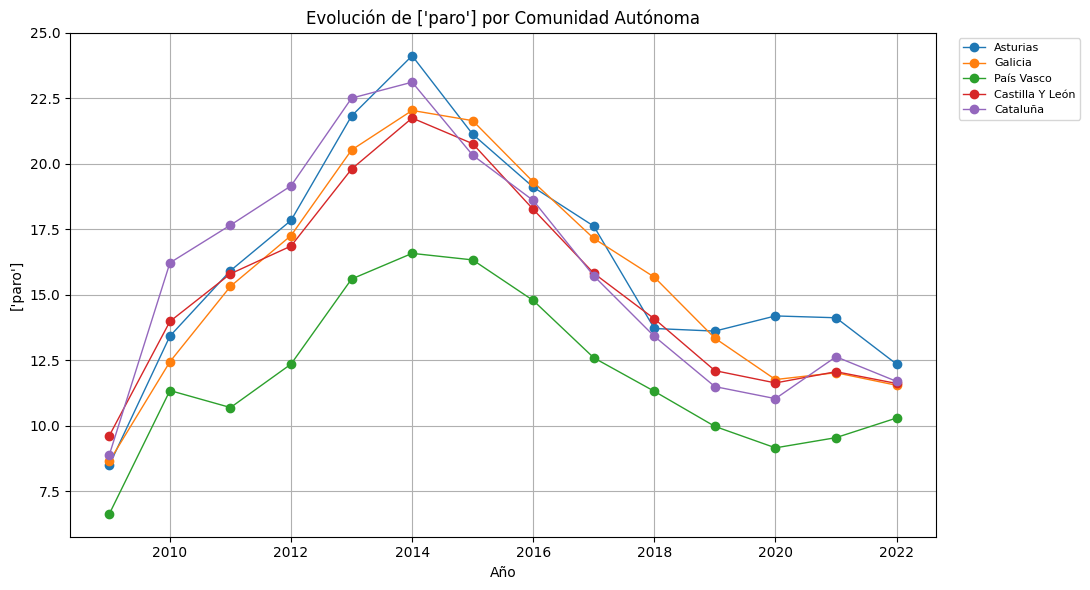

In [25]:
ut.plot_todas_comunidades(df, ['paro'], ['Asturias', 'Galicia', 'País Vasco', 'Castilla Y León', 'Cataluña']);

### Análisis e interpretación de la evolución del paro

La gráfica muestra la evolución temporal de la tasa de paro en distintas comunidades autónomas entre 2009 y 2022. En términos generales, se observa un comportamiento similar en la mayoría de las comunidades, con un incremento progresivo del paro hasta alcanzar un máximo alrededor de los años 2013–2014, seguido de una tendencia descendente sostenida en los años posteriores.

#### Observaciones destacadas

- **Pico común del paro (2013–2014)**  
  Todas las comunidades representadas alcanzan sus valores máximos de paro en torno a este periodo, lo que sugiere la influencia de factores macroeconómicos comunes que afectaron de manera generalizada al mercado laboral.

- **Diferencias en el nivel de paro entre comunidades**  
  Comunidades como Asturias, Galicia y Cataluña presentan niveles de paro relativamente más elevados durante gran parte del periodo analizado.  
  Por el contrario, el País Vasco mantiene de forma consistente valores de paro más bajos, mostrando una menor volatilidad y una recuperación más temprana.

- **Convergencia parcial a partir de 2018**  
  A partir de 2018, las diferencias entre comunidades tienden a reducirse, observándose una estabilización del paro en niveles más bajos, aunque con ligeras oscilaciones en los últimos años.


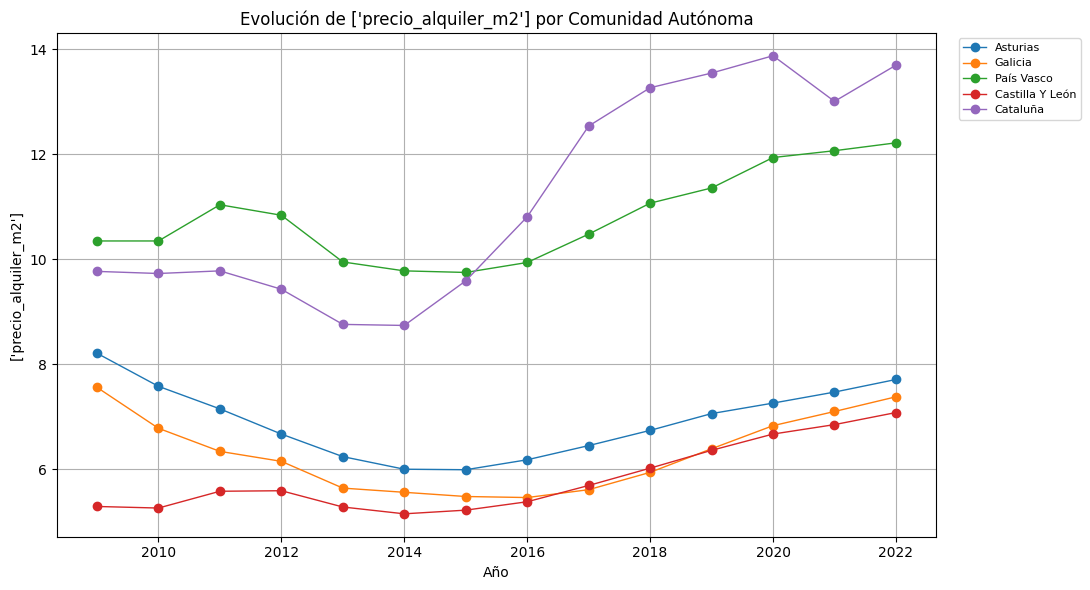

In [26]:
ut.plot_todas_comunidades(df, ['precio_alquiler_m2'], ['Asturias', 'Galicia', 'País Vasco', 'Castilla Y León', 'Cataluña']);

### Análisis e interpretación de la evolución del precio del alquiler por metro cuadrado

La gráfica representa la evolución temporal del precio del alquiler por metro cuadrado en distintas comunidades autónomas entre 2009 y 2022. A diferencia de la tasa de paro, el comportamiento del precio del alquiler muestra una mayor heterogeneidad entre comunidades, así como patrones temporales diferenciados.

#### Observaciones destacadas

- **Descenso generalizado hasta 2013–2014**  
  En la mayoría de las comunidades analizadas se observa una caída progresiva del precio del alquiler por metro cuadrado hasta aproximadamente los años 2013–2014. Este periodo coincide temporalmente con los niveles más elevados de paro observados en el análisis previo, lo que sugiere una posible relación inversa entre ambas variables.

- **Fuerte recuperación a partir de 2015**  
  A partir de 2015, el precio del alquiler inicia una tendencia claramente ascendente en todas las comunidades, aunque con distinta intensidad. Cataluña y el País Vasco destacan por un crecimiento más acusado y sostenido, alcanzando los valores más elevados del conjunto.

- **Diferencias estructurales entre comunidades**  
  - Cataluña presenta los precios de alquiler más altos durante gran parte del periodo, así como una mayor volatilidad en los últimos años.  
  - El País Vasco muestra una evolución ascendente más gradual, con niveles elevados pero relativamente estables.  
  - Asturias, Galicia y Castilla y León mantienen precios sensiblemente inferiores, con variaciones más suaves y una recuperación más moderada.

- **Incremento sostenido en los últimos años**  
  En el tramo final del periodo analizado se aprecia un aumento continuado del precio del alquiler en todas las comunidades, incluso en aquellas con niveles históricamente más bajos, lo que podría reflejar cambios estructurales en el mercado de la vivienda.


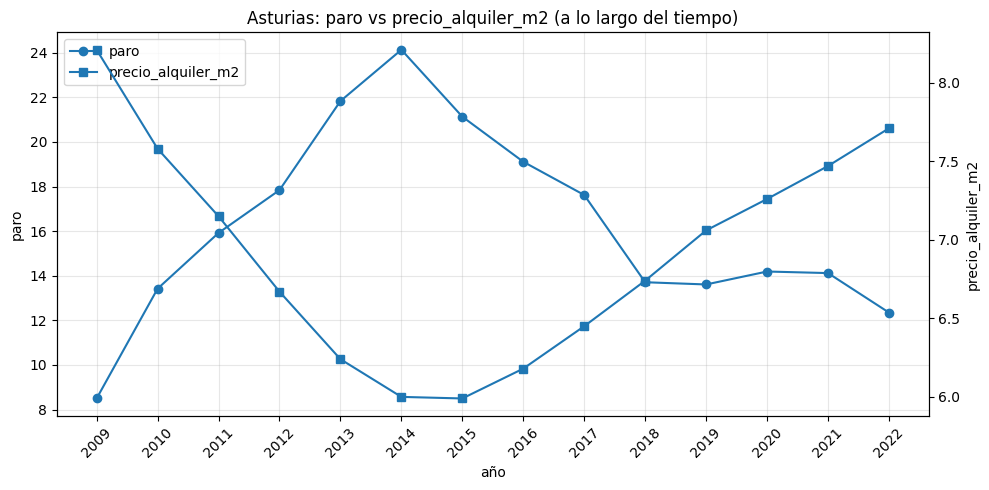

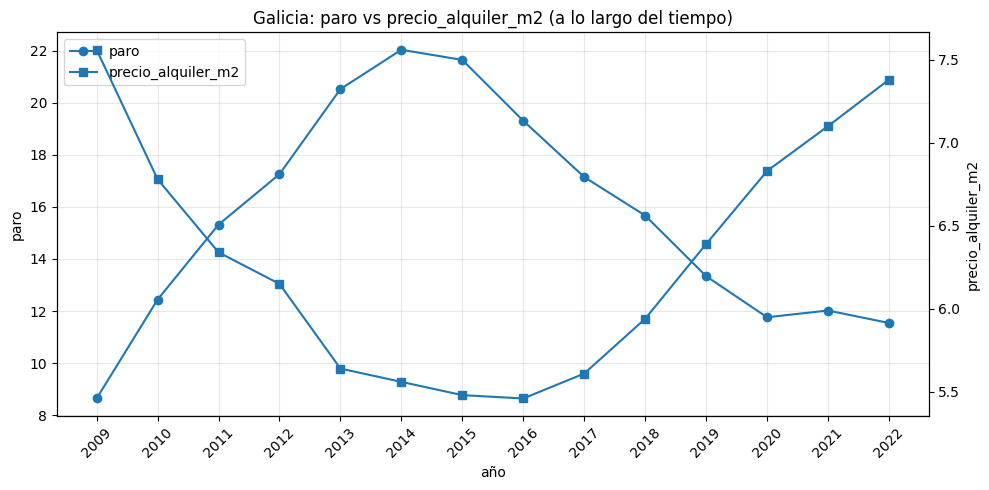

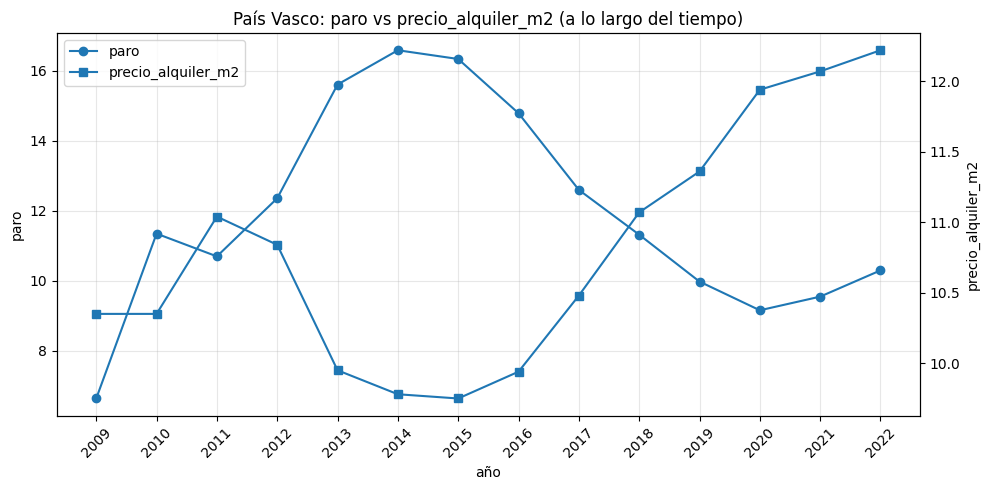

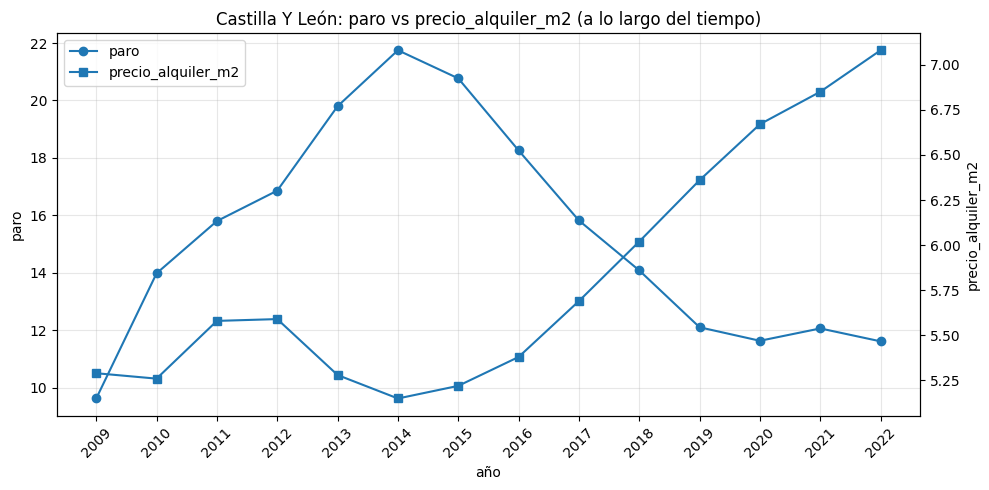

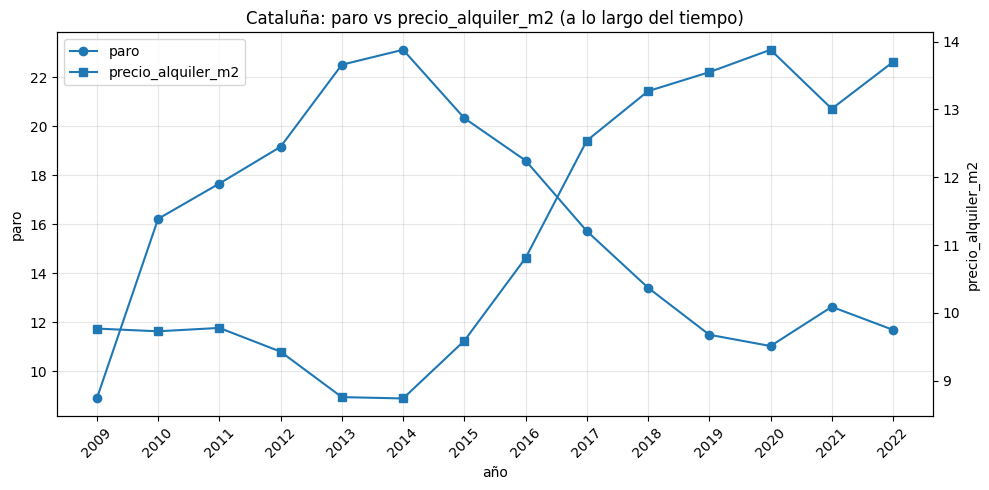

In [27]:
ut.plot_dual_axis(df, ['Asturias', 'Galicia', 'País Vasco', 'Castilla Y León', 'Cataluña'], 'paro', 'precio_alquiler_m2');

### Análisis de la relación entre la tasa de paro y el precio del alquiler por metro cuadrado

Con el objetivo de analizar la relación entre la tasa de paro y el precio del alquiler por metro cuadrado, se representan ambas variables de forma conjunta mediante gráficas con doble eje para distintas comunidades autónomas. Este enfoque permite comparar visualmente la evolución temporal de ambas series y detectar posibles relaciones inversas o patrones comunes.

#### Observaciones destacadas

- **Relación inversa en el periodo 2009–2014**  
  En comunidades como Asturias, Galicia y Castilla y León se observa que el aumento del paro coincide con un descenso del precio del alquiler, lo que sugiere una relación inversa entre ambas variables durante este periodo.

- **Cambio de tendencia a partir de 2015**  
  A partir de 2015, el paro inicia una tendencia descendente mientras que el precio del alquiler comienza a incrementarse de forma sostenida, reforzando visualmente la hipótesis de una relación negativa entre ambas variables.

- **Comportamientos diferenciados según la comunidad**  
  En comunidades como Cataluña y País Vasco, aunque la relación inversa sigue siendo observable, el crecimiento del alquiler es más acusado, lo que indica la posible influencia de factores adicionales no capturados únicamente por la tasa de paro.

- **Desacoplamiento parcial en los últimos años**  
  En los años más recientes se aprecia que, pese a la estabilización o ligera reducción del paro, el precio del alquiler continúa aumentando, lo que sugiere que la relación entre ambas variables no es estrictamente lineal ni constante en el tiempo.


##  Conclusiones del análisis paro vs precio del alquiler

A lo largo de este análisis se ha estudiado la relación entre la tasa de paro y el precio del alquiler por metro cuadrado mediante un enfoque progresivo, combinando análisis univariante y bivariante.

En primer lugar, el análisis univariante permitió identificar las tendencias temporales y las diferencias estructurales entre comunidades autónomas tanto en la tasa de paro como en el precio del alquiler. Posteriormente, el análisis bivariante, apoyado en el cálculo de la correlación y en la representación conjunta mediante gráficas con doble eje, permitió evaluar visual y estadísticamente la relación entre ambas variables.

Los resultados sugieren la existencia de una relación inversa entre el paro y el precio del alquiler, especialmente evidente en el periodo 2009–2014. No obstante, en los años posteriores se observa un desacoplamiento parcial, lo que indica que la evolución del precio del alquiler no puede explicarse únicamente a partir del nivel de desempleo, y que intervienen otros factores adicionales.

En conjunto, este análisis aporta evidencia a favor de la hipótesis planteada, aunque pone de manifiesto la complejidad del fenómeno y la necesidad de considerar múltiples variables en el estudio del mercado del alquiler.


---

## Precio de Alquiler - Riesgo pobreza


In [28]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'precio_alquiler_m2', 'riesgo_pobreza',alpha = 0.05)

Coeficiente de correlación de Spearman entre precio_alquiler_m2 y riesgo_pobreza

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Andalucía', 'Aragón', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Murcia']
 [-0.719, -0.644, -0.829, -0.697, -0.909, -0.846, -0.666, -0.532, -0.745, -0.871, -0.802, -0.881]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Asturias', 'Ceuta', 'Madrid', 'Melilla', 'Navarra', 'País Vasco', 'Rioja']
 [0.091, 0.269, 0.302, 0.618, 0.12, 0.242, 0.144]



Con el objetivo de analizar la relación entre el precio del alquiler por metro cuadrado y el riesgo de pobreza, se estudia la asociación entre ambas variables a partir del cálculo de la correlación y de su representación gráfica para distintas comunidades autónomas.

Los resultados del análisis de correlación indican la existencia de una relación estadísticamente significativa entre ambas variables, lo que permite rechazar la hipótesis nula de ausencia de relación. En consecuencia, se obtiene evidencia a favor de la hipótesis alternativa, según la cual existe una relación entre el precio del alquiler y el riesgo de pobreza.

Para profundizar en este análisis, se seleccionan varias comunidades autónomas en función del valor de la correlación observada: aquellas con los valores más altos, las que presentan los valores más bajos y un caso intermedio. A partir de esta selección, se realiza un análisis gráfico que permite estudiar visualmente la evolución temporal de ambas variables y evaluar la naturaleza de su relación.



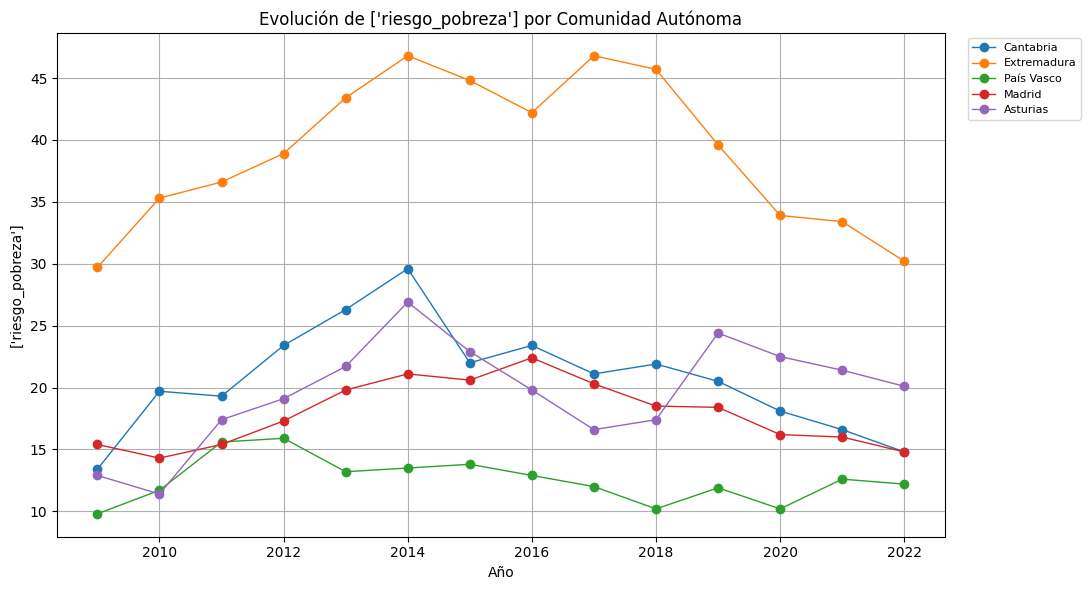

In [29]:
ut.plot_todas_comunidades(df, ['riesgo_pobreza'], ['Cantabria', 'Extremadura', 'País Vasco', 'Madrid', 'Asturias']);

### Análisis e interpretación de la evolución del riesgo de pobreza

La gráfica muestra la evolución temporal del riesgo de pobreza en distintas comunidades autónomas entre 2009 y 2022. A diferencia de otras variables analizadas previamente, el riesgo de pobreza presenta comportamientos claramente diferenciados entre comunidades, tanto en nivel como en tendencia.

#### Observaciones destacadas

- **Niveles persistentemente elevados en Extremadura**  
  Extremadura presenta, durante todo el periodo analizado, los valores más altos de riesgo de pobreza, alcanzando máximos en torno a 2014 y 2017. Aunque se observa una reducción en los últimos años, sus niveles continúan siendo sensiblemente superiores al resto de comunidades.

- **Evolución ascendente seguida de descenso generalizado**  
  En comunidades como Cantabria, Asturias y Madrid se aprecia un aumento progresivo del riesgo de pobreza hasta aproximadamente 2013–2014, seguido de una tendencia descendente a partir de ese punto, lo que sugiere una mejora gradual en los indicadores sociales durante los años posteriores.

- **Estabilidad relativa en el País Vasco**  
  El País Vasco muestra los valores más bajos de riesgo de pobreza durante todo el periodo, con oscilaciones moderadas y una evolución relativamente estable en comparación con el resto de comunidades analizadas.

- **Convergencia parcial en los últimos años**  
  En el tramo final del periodo se observa una cierta convergencia entre comunidades, aunque persisten diferencias estructurales significativas, especialmente entre regiones con distintos niveles de desarrollo económico.


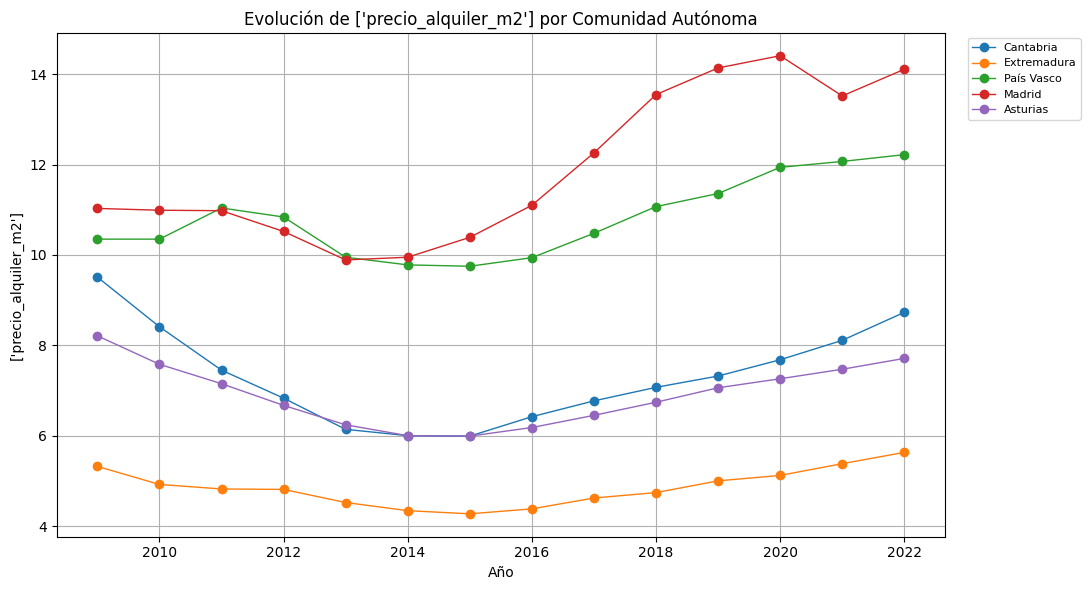

In [30]:
ut.plot_todas_comunidades(df, ['precio_alquiler_m2'], ['Cantabria', 'Extremadura', 'País Vasco', 'Madrid', 'Asturias']);

### Análisis e interpretación de la evolución del precio del alquiler por metro cuadrado

La gráfica muestra la evolución temporal del precio del alquiler por metro cuadrado en Cantabria, Extremadura, País Vasco, Madrid y Asturias entre 2009 y 2022. Se observan diferencias claras tanto en el nivel de precios como en la intensidad de las variaciones entre comunidades.

#### Observaciones destacadas

- **Madrid y País Vasco: niveles de precios más elevados**  
  Madrid presenta los precios de alquiler más altos durante todo el periodo analizado, con una tendencia claramente ascendente a partir de 2014 y un crecimiento especialmente acusado hasta 2020.  
  El País Vasco mantiene también niveles elevados de alquiler, con una evolución más gradual pero sostenida en el tiempo.

- **Extremadura: precios persistentemente bajos**  
  Extremadura muestra los valores más bajos de precio del alquiler por metro cuadrado durante todo el periodo, con una caída inicial hasta 2014 y una recuperación posterior más moderada en comparación con el resto de comunidades.

- **Asturias y Cantabria: evolución intermedia**  
  Asturias y Cantabria presentan precios de alquiler intermedios, con una tendencia descendente hasta 2013–2014 seguida de una recuperación progresiva en los años posteriores.

- **Cambio de tendencia a partir de 2014–2015**  
  En todas las comunidades analizadas se observa un punto de inflexión en torno a 2014–2015, a partir del cual el precio del alquiler inicia una fase de crecimiento sostenido, aunque con distinta intensidad según la comunidad.



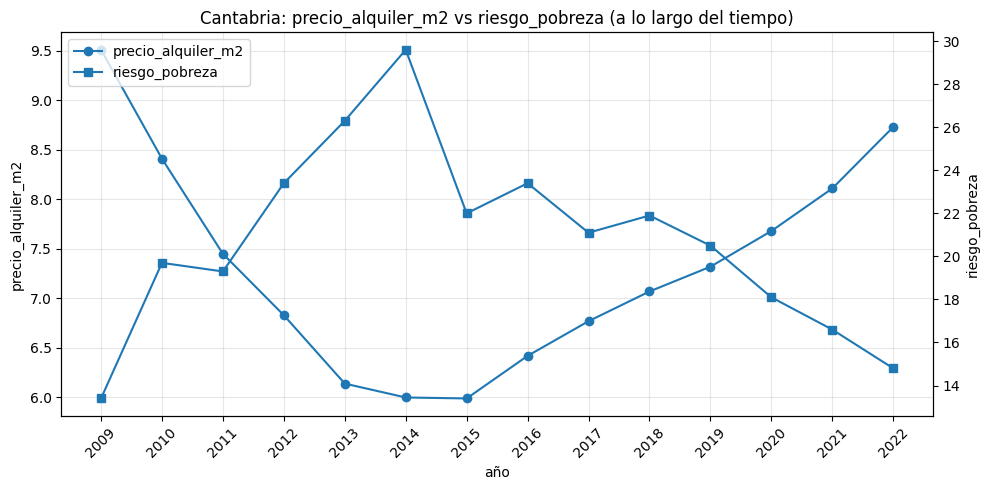

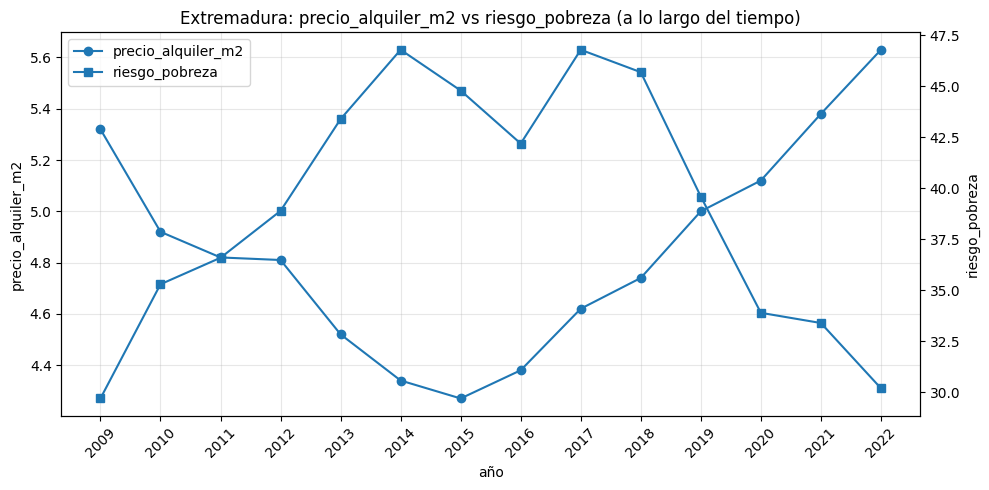

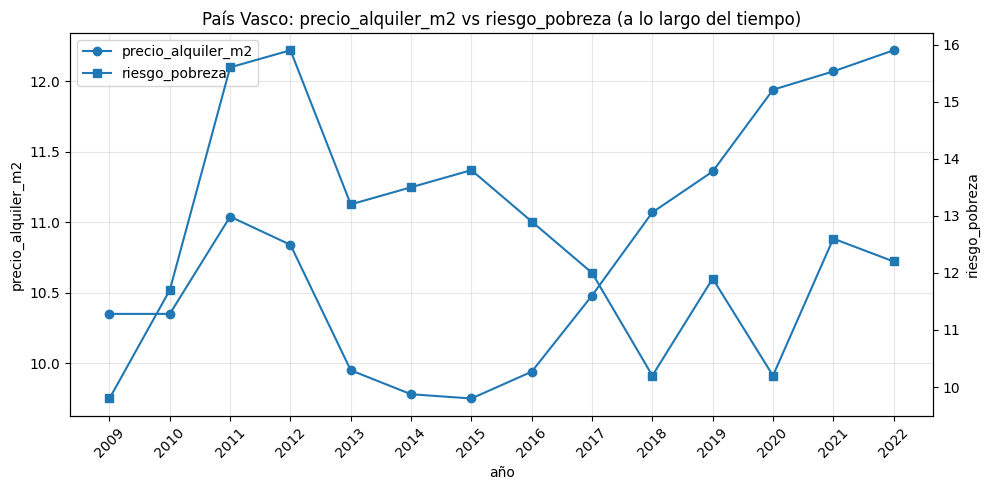

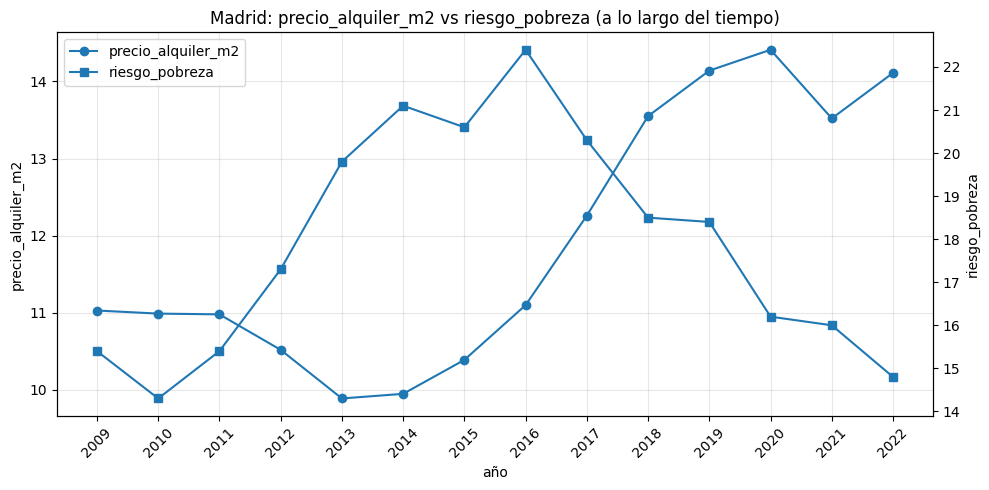

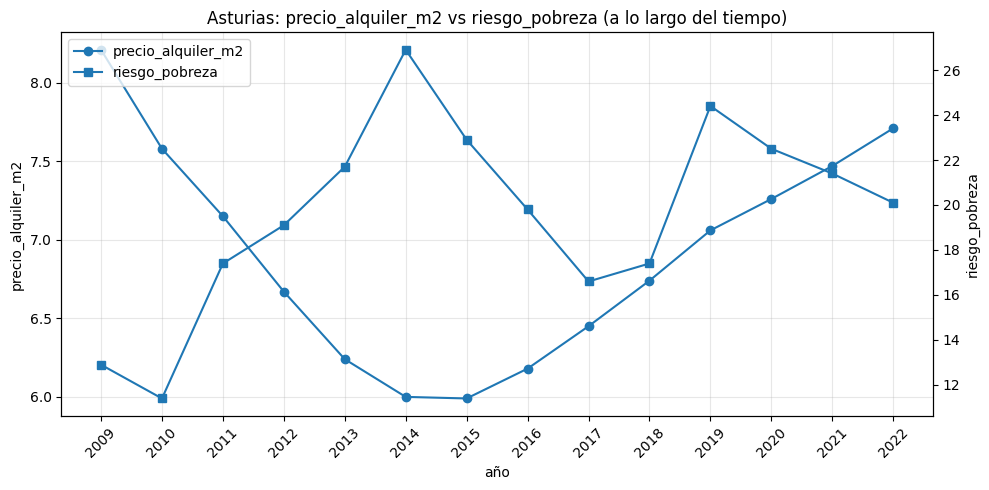

In [31]:
ut.plot_dual_axis(df, ['Cantabria', 'Extremadura', 'País Vasco', 'Madrid', 'Asturias'], 'precio_alquiler_m2', 'riesgo_pobreza');

### Análisis de la relación entre el precio del alquiler por metro cuadrado y el riesgo de pobreza

Con el objetivo de analizar la relación entre el precio del alquiler por metro cuadrado y el riesgo de pobreza, se representan ambas variables de forma conjunta mediante gráficas con doble eje para las comunidades autónomas seleccionadas. Este enfoque permite comparar visualmente la evolución temporal de ambas series y evaluar la naturaleza de su relación a lo largo del tiempo.

Los resultados del análisis de correlación muestran la existencia de una relación estadísticamente significativa y de signo negativo entre ambas variables, lo que permite rechazar la hipótesis nula de ausencia de relación. En consecuencia, se obtiene evidencia a favor de la hipótesis alternativa, según la cual un aumento del precio del alquiler se asocia con una disminución del riesgo de pobreza, y viceversa.

#### Observaciones destacadas

- **Relación inversa marcada en comunidades con alta correlación**  
  En comunidades como Cantabria y Extremadura se observa de forma clara que los periodos de precios de alquiler más bajos coinciden con niveles más elevados de riesgo de pobreza. A partir de 2014–2015, el aumento progresivo del precio del alquiler se acompaña de una reducción sostenida del riesgo de pobreza, reforzando visualmente la relación inversa entre ambas variables.

- **Comportamiento intermedio en Asturias**  
  Asturias presenta una relación inversa moderada entre ambas variables. Tras un periodo inicial de aumento del riesgo de pobreza coincidente con la caída del precio del alquiler, se observa posteriormente una recuperación del precio acompañada de una reducción gradual del riesgo de pobreza, aunque con mayores oscilaciones que en otros territorios.

- **Relación débil en comunidades con baja correlación**  
  En el País Vasco y Madrid, aunque la relación inversa sigue siendo observable en determinados periodos, esta resulta menos consistente. En estas comunidades, el precio del alquiler muestra una tendencia claramente alcista a partir de 2015, mientras que el riesgo de pobreza presenta una evolución más estable o con variaciones menos sincronizadas.

- **Desacoplamiento parcial en los últimos años**  
  En el tramo final del periodo analizado se aprecia que, pese al incremento continuado del precio del alquiler, el riesgo de pobreza no aumenta de forma proporcional, lo que sugiere la influencia de factores adicionales que modulan esta relación.



## Conclusiones finales

En este estudio se ha analizado la relación entre distintas variables socioeconómicas a través de un enfoque exploratorio, combinando análisis univariante y bivariante para dos pares de series temporales: la tasa de paro y el precio del alquiler por metro cuadrado, y el precio del alquiler por metro cuadrado y el riesgo de pobreza.

En el primer análisis, paro frente a precio del alquiler, los resultados del estudio de correlación y las representaciones gráficas sugieren la existencia de una relación inversa en determinados periodos, especialmente entre 2009 y 2014. Sin embargo, esta relación pierde consistencia en los años posteriores, observándose un desacoplamiento parcial entre ambas variables. Esto indica que, aunque el paro puede estar relacionado con el precio del alquiler en contextos económicos específicos, no constituye por sí solo un factor explicativo suficiente de su evolución a largo plazo.

En el segundo análisis, precio del alquiler frente a riesgo de pobreza, se observa una relación inversa en algunas comunidades autónomas y periodos concretos, respaldada por valores de correlación negativos. No obstante, el análisis gráfico revela una elevada heterogeneidad territorial y temporal, así como comportamientos divergentes entre comunidades. En particular, el aumento sostenido del precio del alquiler en los últimos años no se traduce de forma homogénea en cambios equivalentes en el riesgo de pobreza.

En conjunto, los resultados obtenidos no permiten establecer una relación clara, estable y generalizable entre las variables analizadas. Las asociaciones observadas dependen en gran medida del periodo temporal y del contexto regional, lo que sugiere la influencia de múltiples factores adicionales no considerados en este estudio.

Por tanto, este análisis pone de manifiesto que, si bien existen correlaciones y patrones puntuales entre las variables estudiadas, no se dispone de evidencia suficiente para afirmar una relación estructural o causal entre ellas. Este resultado es igualmente relevante, ya que subraya la complejidad del fenómeno y la necesidad de incorporar un enfoque multivariable en futuros estudios.


### Consideraciones metodológicas y análisis multivariante

Como parte de la exploración inicial, se ha analizado la matriz de correlaciones entre todas las variables disponibles, incorporando información sobre la estabilidad de dichas correlaciones. Esta visión global, presentada como figura introductoria del notebook, muestra la ausencia de relaciones fuertes y consistentes entre el precio del alquiler por metro cuadrado y el resto de variables, así como una elevada variabilidad en aquellas asociaciones que presentan mayor intensidad.

A la luz de estos resultados, y en coherencia con los análisis univariantes y bivariantes realizados, no se considera adecuado aplicar un análisis multivariante formal. La ausencia de estructuras de correlación claras y estables podría dar lugar a interpretaciones forzadas o poco representativas del fenómeno analizado. Por este motivo, se opta por mantener un enfoque exploratorio e interpretativo, reconociendo explícitamente las limitaciones del estudio.
